# Spotify Dataset

## 1. Import Libraries

In [ ]:
# Import the Pandas library as pd
import pandas as pd
# Import NumPy for numerical operations
import numpy as np
# Import SQLite so we can create and query a database.
import sqlite3
# Import Matplotlib for creating charts
import matplotlib.pyplot as plt
# Import Seaborn for advanced visualizations
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Extract the dataset

`dataset.csv` is the path of the dataset

In [ ]:
# Storing it in a DataFrame called df
df = pd.read_csv("dataset.csv")
 print("Dataset loaded successfully!")

Dataset loaded successfully!


## 3. Understanding the Dataset

In [ ]:
print("Rows and Columns:")
# The number of rows and columns
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())
# Display the first 5 rows of the dataset
df.head()

Rows and Columns:
(114000, 21)

Columns:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 4. Checking the Missing values

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


## 5. Check Duplicate values

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## 6. Transform: Remove Duplicates

Using `track_id` since it's unique.

In [ ]:
df = df.drop_duplicates(subset=['track_id'])

print("Duplicates removed!")
print(df.shape)

Duplicates removed!
(89741, 21)


## 7. Handle Missing Values

In [ ]:
df = df.dropna()

print("Missing values removed!")
print(df.shape)

Missing values removed!
(89740, 21)


Getting song duration in milliseconds

## 8. Feature Engineering: Duration in Minutes

In [ ]:
df['duration_min'] = df['duration_ms'] / 60000

df[['duration_ms', 'duration_min']].head()

,duration_ms,duration_min
0,230666,3.844433
1,149610,2.493500
2,210826,3.513767
3,201933,3.365550
4,198853,3.314217


## 9. Feature Engineering: Popularity Categories

In [ ]:
def popularity_level(pop):
    if pop >= 80:
        return "Hit"
    elif pop >= 60:
        return "Popular"
    elif pop >= 40:
        return "Moderate"
    else:
        return "Low"

df['popularity_level'] = df['popularity'].apply(popularity_level)

df[['popularity', 'popularity_level']].head()

,popularity,popularity_level
0,73,Popular
1,55,Moderate
2,57,Moderate
3,71,Popular
4,82,Hit


## 10. Feature Engineering: Energy Categories

In [ ]:
def energy_level(energy):
    if energy >= 0.7:
        return "High"
    elif energy >= 0.4:
        return "Medium"
    else:
        return "Low"

df['energy_level'] = df['energy'].apply(energy_level)

df[['energy', 'energy_level']].head()

,energy,energy_level
0,0.4610,Medium
1,0.1660,Low
2,0.3590,Low
3,0.0596,Low
4,0.4430,Medium


## 11. Feature Engineering: Mood Categories (using Valence)

In [ ]:
def mood(valence):
    if valence >= 0.7:
        return "Happy"
    elif valence >= 0.4:
        return "Neutral"
    else:
        return "Sad"

df['mood'] = df['valence'].apply(mood)

df[['valence', 'mood']].head()

,valence,mood
0,0.715,Happy
1,0.267,Sad
2,0.120,Sad
3,0.143,Sad
4,0.167,Sad


## 12. Feature Engineering: Tempo Categories

In [ ]:
def tempo_category(tempo):
    if tempo < 90:
        return "Slow"
    elif tempo < 120:
        return "Medium"
    else:
        return "Fast"

df['tempo_category'] = df['tempo'].apply(tempo_category)

df[['tempo', 'tempo_category']].head()

,tempo,tempo_category
0,87.917,Slow
1,77.489,Slow
2,76.332,Slow
3,181.740,Fast
4,119.949,Medium


## 13. Validate Data

In [ ]:
print("Popularity Check:", df['popularity'].between(0, 100).all())
print("Energy Check:", df['energy'].between(0, 1).all())
print("Danceability Check:", df['danceability'].between(0, 1).all())

Popularity Check: True
Energy Check: True
Danceability Check: True


## 14. Save Cleaned Dataset

In [ ]:
df.to_csv("spotify_cleaned.csv", index=False)

print("Cleaned CSV saved.")

Cleaned CSV saved.


## 15. Load: Write Data into SQLite

In [ ]:
conn = sqlite3.connect("spotify.db")

df.to_sql(
    "spotify_tracks",
    conn,
    if_exists="replace",
    index=False
)

print("Data loaded into SQLite!")

Data loaded into SQLite!


## 16. SQL Analytics Queries

The SQL queries are the most important part after ETL, since they show that the loaded data can actually be used for analysis.

### Query 1: Top 10 Most Popular Songs

In [ ]:
query = """
SELECT
    track_name,
    artists,
    popularity
FROM spotify_tracks
ORDER BY popularity DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)
result

,track_name,artists,popularity
0,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,100
1,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,99
2,I'm Good (Blue),David Guetta;Bebe Rexha,98
3,La Bachata,Manuel Turizo,98
4,Me Porto Bonito,Bad Bunny;Chencho Corleone,97
5,Tití Me Preguntó,Bad Bunny,97
6,Under The Influence,Chris Brown,96
7,Efecto,Bad Bunny,96
8,I Ain't Worried,OneRepublic,96
9,Ojitos Lindos,Bad Bunny;Bomba Estéreo,95


**Insight:** Which songs are currently the most popular.

### Query 2: Top 10 Artists by Average Popularity

In [ ]:
query = """
SELECT
    artists,
    ROUND(AVG(popularity),2) AS avg_popularity
FROM spotify_tracks
GROUP BY artists
ORDER BY avg_popularity DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)
result

,artists,avg_popularity
0,Sam Smith;Kim Petras,100.0
1,Bizarrap;Quevedo,99.0
2,Manuel Turizo,98.0
3,Bad Bunny;Chencho Corleone,97.0
4,Bad Bunny;Bomba Estéreo,95.0
5,Joji,94.0
6,Beyoncé,93.0
7,Rema;Selena Gomez,92.0
8,Harry Styles,92.0
9,Rauw Alejandro;Lyanno;Brray,91.0


**Insight:** Which artists consistently produce popular songs.

### Query 3: Most Popular Genres

In [ ]:
query = """
SELECT
    track_genre,
    ROUND(AVG(popularity),2) AS avg_popularity
FROM spotify_tracks
GROUP BY track_genre
ORDER BY avg_popularity DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)
result

,track_genre,avg_popularity
0,k-pop,59.42
1,pop-film,59.10
2,metal,56.42
3,chill,53.74
4,latino,51.79
5,sad,51.11
6,grunge,50.59
7,indian,49.77
8,anime,48.78
9,emo,48.50


**Insight:** Which genres attract listeners.

### Query 4: Genre-wise Song Count

In [ ]:
query = """
SELECT
    track_genre,
    COUNT(*) AS total_tracks
FROM spotify_tracks
GROUP BY track_genre
ORDER BY total_tracks DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)
result

,track_genre,total_tracks
0,acoustic,1000
1,tango,999
2,cantopop,999
3,ambient,999
4,alt-rock,999
5,afrobeat,999
6,study,998
7,forro,998
8,disney,998
9,chicago-house,998


**Insight:** Most represented genres in the dataset.

### Query 5: Mood Analysis

In [ ]:
query = """
SELECT
    mood,
    COUNT(*) AS total_songs,
    ROUND(AVG(popularity),2) AS avg_popularity
FROM spotify_tracks
GROUP BY mood;
"""

result = pd.read_sql(query, conn)
result

,mood,total_songs,avg_popularity
0,Happy,20704,31.82
1,Neutral,30111,33.91
2,Sad,38925,33.38


**Insight:** Are happy songs more popular?

### Query 6: Energy Level Analysis

In [ ]:
query = """
SELECT
    energy_level,
    COUNT(*) AS songs,
    ROUND(AVG(popularity),2) AS avg_popularity
FROM spotify_tracks
GROUP BY energy_level;
"""

result = pd.read_sql(query, conn)
result

,energy_level,songs,avg_popularity
0,High,42119,32.83
1,Low,17802,30.51
2,Medium,29819,35.32


**Insight:** Does high energy lead to popularity?

### Query 7: Average Danceability by Genre

In [ ]:
query = """
SELECT
    track_genre,
    ROUND(AVG(danceability),2) AS avg_danceability
FROM spotify_tracks
GROUP BY track_genre
ORDER BY avg_danceability DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)
result

,track_genre,avg_danceability
0,kids,0.78
1,chicago-house,0.77
2,latino,0.76
3,reggaeton,0.74
4,reggae,0.73
5,minimal-techno,0.73
6,latin,0.73
7,hip-hop,0.73
8,dancehall,0.73
9,detroit-techno,0.72


**Insight:** Which genres are most danceable.

### Query 8: Explicit vs Non-Explicit Songs

In [ ]:
query = """
SELECT
    explicit,
    COUNT(*) AS songs,
    ROUND(AVG(popularity),2) AS avg_popularity
FROM spotify_tracks
GROUP BY explicit;
"""

result = pd.read_sql(query, conn)
result

,explicit,songs,avg_popularity
0,0,82036,32.85
1,1,7704,36.89


**Insight:** Do explicit songs perform better?

### Query 9: Longest Songs

In [ ]:
query = """
SELECT
    track_name,
    artists,
    ROUND(duration_min,2) AS duration_min
FROM spotify_tracks
ORDER BY duration_min DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)
result

,track_name,artists,duration_min
0,Unity (Voyage Mix) Pt. 1,Tale Of Us,87.29
1,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,79.82
2,The Lab 03 - Continuous DJ Mix Part 1,Seth Troxler,78.84
3,Amnesia Ibiza Underground 10 DJ Mix,Loco Dice,76.06
4,House of Om - Mark Farina - Continuous Mix,Mark Farina,74.13
5,Live In Tokyo - Continuous Mix,Mark Farina,72.33
6,Greenhouse Construction,Mark Farina,72.25
7,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",Lenzman;Dan Stezo,70.77
8,Ocean Waves Sounds,Ocean Sounds,68.67
9,Internal Flight (Remastered),Estas Tonne,64.60


**Insight:** Longest tracks in the dataset.

### Query 10: Most Energetic Genres

In [ ]:
query = """
SELECT
    track_genre,
    ROUND(AVG(energy),2) AS avg_energy
FROM spotify_tracks
GROUP BY track_genre
ORDER BY avg_energy DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)
result

,track_genre,avg_energy
0,grindcore,0.93
1,death-metal,0.93
2,happy,0.91
3,metalcore,0.90
4,hardstyle,0.90
5,drum-and-bass,0.88
6,black-metal,0.88
7,party,0.87
8,j-idol,0.87
9,heavy-metal,0.87


**Insight:** Genres with the highest average energy.

### Query 11: Happiest Genres (Using Valence)

In [ ]:
query = """
SELECT
    track_genre,
    ROUND(AVG(valence),2) AS happiness_score
FROM spotify_tracks
GROUP BY track_genre
ORDER BY happiness_score DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)
result

,track_genre,happiness_score
0,salsa,0.81
1,forro,0.76
2,rockabilly,0.74
3,ska,0.72
4,samba,0.71
5,pagode,0.70
6,afrobeat,0.70
7,children,0.69
8,party,0.68
9,kids,0.68


**Insight:** Genres with the highest average valence (happiness).

### Query 12: Most Acoustic Genres

In [ ]:
query = """
SELECT
    track_genre,
    ROUND(AVG(acousticness),2) AS avg_acousticness
FROM spotify_tracks
GROUP BY track_genre
ORDER BY avg_acousticness DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)
result

,track_genre,avg_acousticness
0,classical,0.92
1,romance,0.86
2,tango,0.85
3,opera,0.83
4,new-age,0.83
5,ambient,0.78
6,jazz,0.77
7,guitar,0.77
8,disney,0.74
9,comedy,0.73


**Insight:** Genres with the highest average acousticness.

### Query 13: Popularity by Tempo Category

In [ ]:
query = """
SELECT
    tempo_category,
    ROUND(AVG(popularity),2) AS avg_popularity
FROM spotify_tracks
GROUP BY tempo_category;
"""

result = pd.read_sql(query, conn)
result

,tempo_category,avg_popularity
0,Fast,33.17
1,Medium,33.58
2,Slow,32.47


**Insight:** Do faster or slower songs tend to be more popular?

### Query 14: Top Genres with Highest Danceability and Popularity

In [ ]:
query = """
SELECT
    track_genre,
    ROUND(AVG(danceability),2) AS avg_danceability,
    ROUND(AVG(popularity),2) AS avg_popularity
FROM spotify_tracks
GROUP BY track_genre
ORDER BY avg_popularity DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)
result

,track_genre,avg_danceability,avg_popularity
0,k-pop,0.64,59.42
1,pop-film,0.59,59.10
2,metal,0.48,56.42
3,chill,0.67,53.74
4,latino,0.76,51.79
5,sad,0.70,51.11
6,grunge,0.46,50.59
7,indian,0.59,49.77
8,anime,0.54,48.78
9,emo,0.60,48.50


**Insight:** Genres that combine both danceability and popularity.

### Query 15: Overall Dataset KPIs

In [ ]:
query = """
SELECT
    COUNT(*) AS total_tracks,
    COUNT(DISTINCT artists) AS unique_artists,
    COUNT(DISTINCT track_genre) AS unique_genres,
    ROUND(AVG(popularity),2) AS avg_popularity,
    ROUND(AVG(duration_min),2) AS avg_duration
FROM spotify_tracks;
"""

result = pd.read_sql(query, conn)
result

,total_tracks,unique_artists,unique_genres,avg_popularity,avg_duration
0,89740,31437,113,33.2,3.82


**Insight:** High-level KPIs for the whole dataset.

**For a portfolio/interview highlight reel**, the 5 most compelling queries are usually: Top 10 Popular Songs, Most Popular Genres, Mood Analysis, Energy Level Analysis, and Explicit vs Non-Explicit Songs — paired with the correlation heatmap below.

## 17. Correlation Analysis

In [ ]:
features = [
    'popularity',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_min'
]

corr_matrix = df[features].corr()

corr_matrix

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
popularity,1.000000,0.064275,0.013725,0.071674,-0.047086,-0.038828,-0.127477,-0.013857,-0.011508,0.007280,-0.023157
danceability,0.064275,1.000000,0.143913,0.271838,0.109519,-0.177040,-0.194750,-0.132237,0.492578,-0.021329,-0.064139
energy,0.013725,0.143913,1.000000,0.758774,0.141332,-0.732569,-0.181038,0.188940,0.256317,0.258629,0.063258
loudness,0.071674,0.271838,0.758774,1.000000,0.055295,-0.582664,-0.434719,0.077238,0.289095,0.228660,0.000360
speechiness,-0.047086,0.109519,0.141332,0.055295,1.000000,0.005124,-0.099659,0.225100,0.032935,0.004033,-0.060751
acousticness,-0.038828,-0.177040,-0.732569,-0.582664,0.005124,1.000000,0.096072,-0.019073,-0.103781,-0.220252,-0.108478
instrumentalness,-0.127477,-0.194750,-0.181038,-0.434719,-0.099659,0.096072,1.000000,-0.087157,-0.330756,-0.056885,0.117372
liveness,-0.013857,-0.132237,0.188940,0.077238,0.225100,-0.019073,-0.087157,1.000000,0.012322,-0.006113,0.008109
valence,-0.011508,0.492578,0.256317,0.289095,0.032935,-0.103781,-0.330756,0.012322,1.000000,0.090617,-0.147018
tempo,0.007280,-0.021329,0.258629,0.228660,0.004033,-0.220252,-0.056885,-0.006113,0.090617,1.000000,0.026004


## 18. Correlation Heatmap

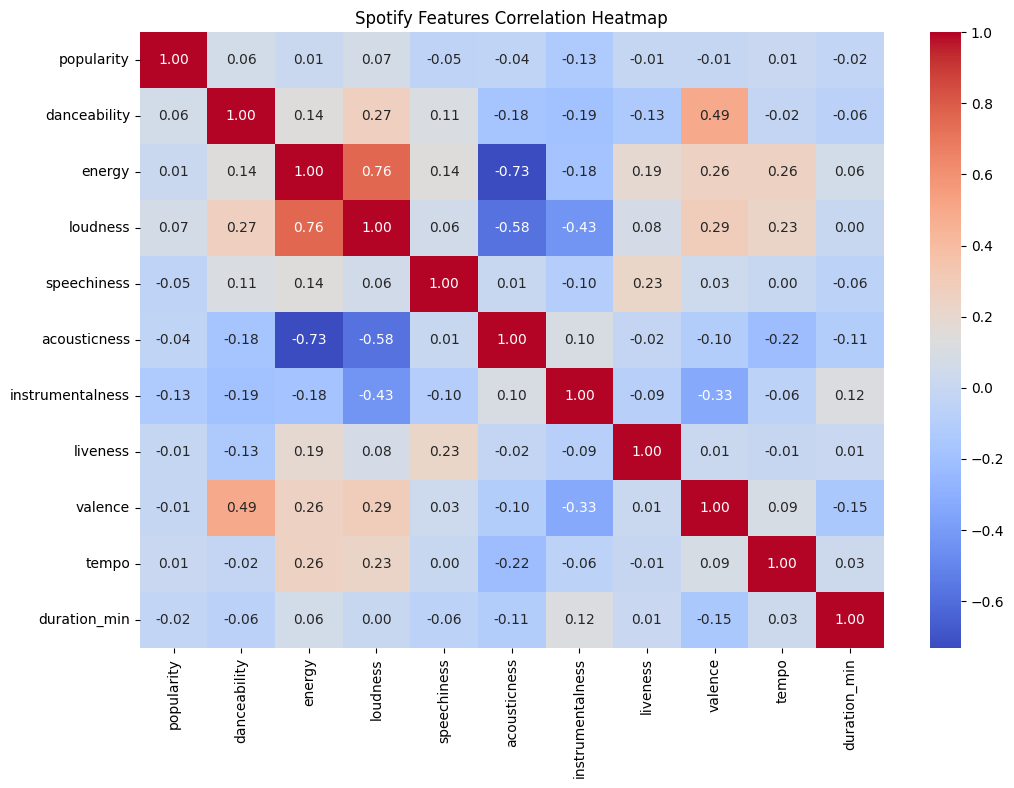

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Spotify Features Correlation Heatmap")
plt.show()

## 19. Correlation with Popularity

In [ ]:
pop_corr = corr_matrix['popularity'].sort_values(ascending=False)

pop_corr

,popularity
popularity,1.000000
loudness,0.071674
danceability,0.064275
energy,0.013725
tempo,0.007280
valence,-0.011508
liveness,-0.013857
duration_min,-0.023157
acousticness,-0.038828
speechiness,-0.047086


## 20. Danceability vs Popularity

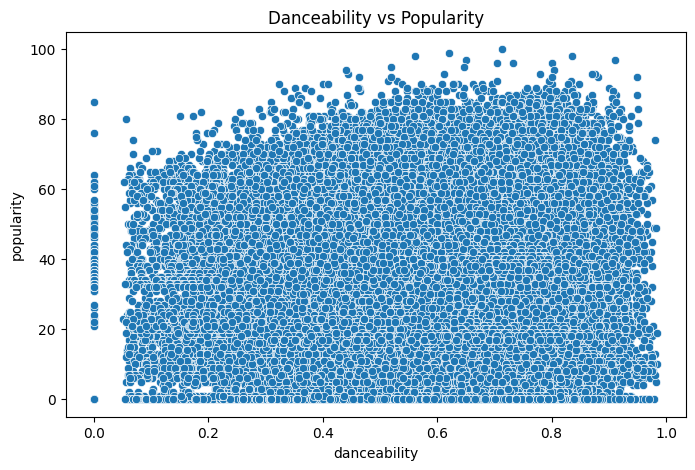

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='danceability',
    y='popularity'
)

plt.title("Danceability vs Popularity")
plt.show()

## 21. Energy vs Popularity

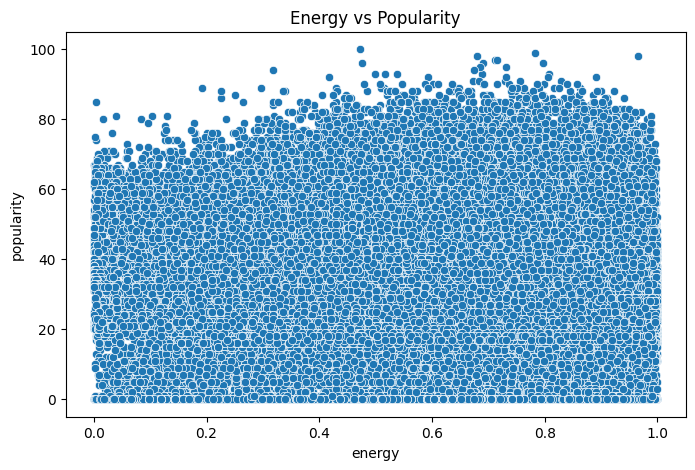

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='energy',
    y='popularity'
)

plt.title("Energy vs Popularity")
plt.show()

## 22. Top Genres by Popularity

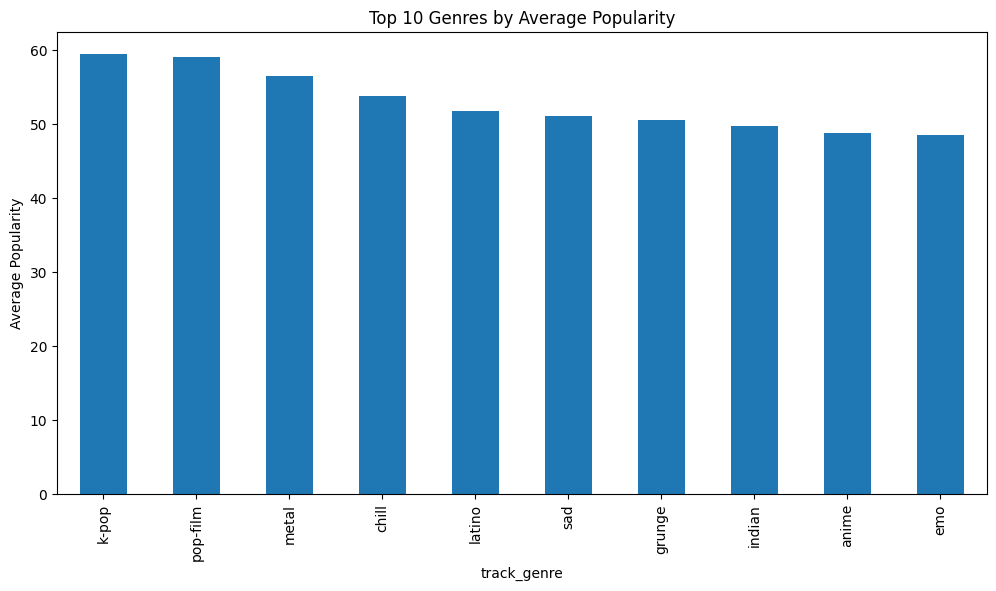

In [ ]:
top_genres = (
    df.groupby('track_genre')['popularity']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top_genres.plot(kind='bar')
plt.title("Top 10 Genres by Average Popularity")
plt.ylabel("Average Popularity")
plt.show()